In [ ]:
!pip install torchattacks
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time
import torchattacks
import os

# Подключаем Google Диск
from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ Рабочее устройство: {device}")
if torch.cuda.is_available():
    print(f"🚀 Модель GPU: {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 16.1 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.19
    Uninstalling idna-3.19:
      Successfully uninstalled idna-3.19
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: re

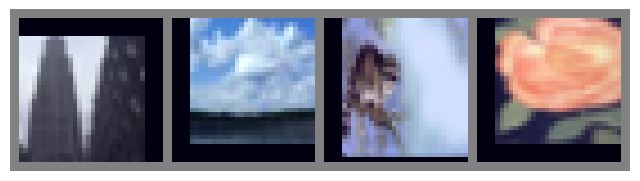

Истинные классы:
skyscraper | cloud | raccoon | rose


In [ ]:
data_path = '/content/drive/MyDrive/Colab_Data/CIFAR100'
os.makedirs(data_path, exist_ok=True)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)) # Точные метрики для CIFAR-100
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# Загружаем CIFAR-100
trainset = torchvision.datasets.CIFAR100(root=data_path, train=True, download=True, transform=train_transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR100(root=data_path, train=False, download=True, transform=test_transform)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# ФИКС ОШИБКИ: Автоматически берем 100 классов прямо из датасета
classes = trainset.classes

def imshow(img):
    img = img * 0.2761 + 0.5071 # Денормализация под CIFAR-100
    npimg = img.numpy()
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Тестируем визуализацию
images, labels = next(iter(trainloader))
imshow(torchvision.utils.make_grid(images[:4]))
print('Истинные классы:')
print(' | '.join(f'{classes[labels[j].item()]}' for j in range(4)))

In [ ]:
def get_resnet18_cifar(num_classes=100):
    model = models.resnet18(weights=None)
    # Адаптация первого слоя под маленькие картинки CIFAR
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = get_resnet18_cifar(num_classes=100).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"✅ Индустриальная модель ResNet-18 загружена на {device}")

✅ Индустриальная модель ResNet-18 загружена на cuda


In [ ]:
epochs = 15
print(f"🚀 Начинаем обучение базовой модели ResNet-18 ({epochs} эпох)...\n")

for epoch in range(epochs):
    start_time = time.time()
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # Валидация
    model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    print(f"Эпоха [{epoch+1}/{epochs}] | Train Acc: {100 * correct_train / total_train:.2f}% | Test Acc: {100 * correct_test / total_test:.2f}% | Время: {time.time()-start_time:.1f} сек")

# Сохраняем модель
torch.save(model.state_dict(), '/content/drive/MyDrive/Colab_Data/resnet18_cifar100_base.pth')
print("\n✅ Обучение завершено. Веса сохранены на Диск!")

🚀 Начинаем обучение базовой модели ResNet-18 (15 эпох)...

Эпоха [1/15] | Train Acc: 13.46% | Test Acc: 18.77% | Время: 47.4 сек
Эпоха [2/15] | Train Acc: 27.70% | Test Acc: 29.80% | Время: 45.9 сек
Эпоха [3/15] | Train Acc: 38.14% | Test Acc: 39.81% | Время: 45.2 сек
Эпоха [4/15] | Train Acc: 45.13% | Test Acc: 44.84% | Время: 45.8 сек
Эпоха [5/15] | Train Acc: 50.64% | Test Acc: 45.93% | Время: 46.6 сек
Эпоха [6/15] | Train Acc: 55.27% | Test Acc: 52.73% | Время: 46.3 сек
Эпоха [7/15] | Train Acc: 59.13% | Test Acc: 56.55% | Время: 46.3 сек
Эпоха [8/15] | Train Acc: 62.24% | Test Acc: 56.86% | Время: 45.6 сек
Эпоха [9/15] | Train Acc: 65.02% | Test Acc: 57.67% | Время: 45.2 сек
Эпоха [10/15] | Train Acc: 67.89% | Test Acc: 60.49% | Время: 45.2 сек
Эпоха [11/15] | Train Acc: 70.57% | Test Acc: 61.56% | Время: 45.2 сек
Эпоха [12/15] | Train Acc: 72.66% | Test Acc: 62.82% | Время: 45.2 сек
Эпоха [13/15] | Train Acc: 74.83% | Test Acc: 62.39% | Время: 45.3 сек
Эпоха [14/15] | Train Acc: 

In [ ]:
print("🛡️ Начинаем тестирование модели под атаками...\n")
model.eval()

# Задаем уровни шума (для статьи берем стандартные)
epsilons = [0, 2/255, 4/255, 8/255]
fgsm_accs = []
pgd_accs = []

for eps in epsilons:
    if eps == 0:
        # Тест без атаки (мы его уже знаем из ячейки 4, но прогоним еще раз для точности)
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, pred = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()
        fgsm_accs.append(100 * correct / total)
        pgd_accs.append(100 * correct / total)
        print(f"Epsilon: 0.0000 | Точность (Чистые данные): {100 * correct / total:.2f}%")
        continue

    # Инициализируем готовые атаки из библиотеки
    atk_fgsm = torchattacks.FGSM(model, eps=eps)
    atk_pgd = torchattacks.PGD(model, eps=eps, alpha=eps/4, steps=7)

    # 1. Тест FGSM
    correct_fgsm, total = 0, 0
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        adv_inputs = atk_fgsm(inputs, labels) # Вся магия атаки в одной строчке!
        outputs = model(adv_inputs)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct_fgsm += (pred == labels).sum().item()

    # 2. Тест PGD
    correct_pgd = 0
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        adv_inputs = atk_pgd(inputs, labels)
        outputs = model(adv_inputs)
        _, pred = torch.max(outputs, 1)
        correct_pgd += (pred == labels).sum().item()

    acc_f = 100 * correct_fgsm / total
    acc_p = 100 * correct_pgd / total
    fgsm_accs.append(acc_f)
    pgd_accs.append(acc_p)

    print(f"Epsilon: {eps:.4f} | Точность FGSM: {acc_f:.2f}% | Точность PGD: {acc_p:.2f}%")

print("\n✅ Данные собраны! Сохрани эти проценты, они пойдут прямо в графики для статьи.")

🛡️ Начинаем тестирование модели под атаками...

Epsilon: 0.0000 | Точность (Чистые данные): 64.72%
Epsilon: 0.0078 | Точность FGSM: 23.54% | Точность PGD: 17.81%
Epsilon: 0.0157 | Точность FGSM: 21.02% | Точность PGD: 12.31%
Epsilon: 0.0314 | Точность FGSM: 17.24% | Точность PGD: 6.39%

✅ Данные собраны! Сохрани эти проценты, они пойдут прямо в графики для статьи.


In [ ]:
print("🛡️ Начинаем Смешанное Adversarial Training...\n")
adv_model = get_resnet18_cifar(num_classes=100).to(device)
optimizer_adv = optim.Adam(adv_model.parameters(), lr=0.001)
atk_train = torchattacks.PGD(adv_model, eps=4/255, alpha=1/255, steps=3)

epochs_adv = 15
for epoch in range(epochs_adv):
    start_time = time.time()
    adv_model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. Генерируем отравленные картинки
        adv_inputs = atk_train(inputs, labels)

        optimizer_adv.zero_grad()

        # 2. Считаем ошибку на чистых данных
        outputs_clean = adv_model(inputs)
        loss_clean = criterion(outputs_clean, labels)

        # 3. Считаем ошибку на атакованных данных
        outputs_adv = adv_model(adv_inputs)
        loss_adv = criterion(outputs_adv, labels)

        # 4. Смешиваем опыт (50/50)
        loss = 0.5 * loss_clean + 0.5 * loss_adv
        loss.backward()
        optimizer_adv.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs_clean.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train
    print(f"Эпоха защиты [{epoch+1}/{epochs_adv}] | Train Acc (Чистые): {train_acc:.2f}% | Время: {time.time()-start_time:.1f} сек")

torch.save(adv_model.state_dict(), '/content/drive/MyDrive/Colab_Data/resnet18_cifar100_adv_mixed.pth')
print("\n✅ Идеальная смешанная защита готова!")

🛡️ Начинаем Смешанное Adversarial Training...

Эпоха защиты [1/15] | Train Acc (Чистые): 14.89% | Время: 163.1 сек
Эпоха защиты [2/15] | Train Acc (Чистые): 28.80% | Время: 162.9 сек
Эпоха защиты [3/15] | Train Acc (Чистые): 38.97% | Время: 163.5 сек
Эпоха защиты [4/15] | Train Acc (Чистые): 46.27% | Время: 163.8 сек
Эпоха защиты [5/15] | Train Acc (Чистые): 51.49% | Время: 163.0 сек
Эпоха защиты [6/15] | Train Acc (Чистые): 55.87% | Время: 163.5 сек
Эпоха защиты [7/15] | Train Acc (Чистые): 59.34% | Время: 163.7 сек
Эпоха защиты [8/15] | Train Acc (Чистые): 62.29% | Время: 162.8 сек
Эпоха защиты [9/15] | Train Acc (Чистые): 65.33% | Время: 163.1 сек
Эпоха защиты [10/15] | Train Acc (Чистые): 67.73% | Время: 163.5 сек
Эпоха защиты [11/15] | Train Acc (Чистые): 70.19% | Время: 163.8 сек
Эпоха защиты [12/15] | Train Acc (Чистые): 72.29% | Время: 163.2 сек
Эпоха защиты [13/15] | Train Acc (Чистые): 74.25% | Время: 162.8 сек
Эпоха защиты [14/15] | Train Acc (Чистые): 76.10% | Время: 162.9 

In [8]:
print("🛡️ Тестируем защищенную модель (Adversarial Training)...\n")
adv_model.eval()

# Те же уровни шума, что и вчера
epsilons = [0, 2/255, 4/255, 8/255]
adv_fgsm_accs = []
adv_pgd_accs = []

for eps in epsilons:
    if eps == 0:
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = adv_model(inputs)
                _, pred = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()
        acc_clean = 100 * correct / total
        adv_fgsm_accs.append(acc_clean)
        adv_pgd_accs.append(acc_clean)
        print(f"Epsilon: 0.0000 |Accuracy (Clean data): {acc_clean:.2f}%")
        continue

    # Инициализируем атаки для защищенной модели
    atk_fgsm = torchattacks.FGSM(adv_model, eps=eps)
    atk_pgd = torchattacks.PGD(adv_model, eps=eps, alpha=eps/4, steps=7)

    # 1. Тест защиты против FGSM
    correct_fgsm, total = 0, 0
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        adv_inputs = atk_fgsm(inputs, labels)
        outputs = adv_model(adv_inputs)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct_fgsm += (pred == labels).sum().item()

    # 2. Тест защиты против PGD
    correct_pgd = 0
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        adv_inputs = atk_pgd(inputs, labels)
        outputs = adv_model(adv_inputs)
        _, pred = torch.max(outputs, 1)
        correct_pgd += (pred == labels).sum().item()

    acc_f = 100 * correct_fgsm / total
    acc_p = 100 * correct_pgd / total
    adv_fgsm_accs.append(acc_f)
    adv_pgd_accs.append(acc_p)

    print(f"Epsilon: {eps:.4f} | FGSM accuracy: {acc_f:.2f}% | PGD accuracy: {acc_p:.2f}%")

🛡️ Тестируем защищенную модель (Adversarial Training)...

Epsilon: 0.0000 |Accuracy (Clean data): 57.37%
Epsilon: 0.0078 | FGSM accuracy: 30.52% | PGD accuracy: 26.48%
Epsilon: 0.0157 | FGSM accuracy: 28.18% | PGD accuracy: 20.89%
Epsilon: 0.0314 | FGSM accuracy: 24.47% | PGD accuracy: 12.66%


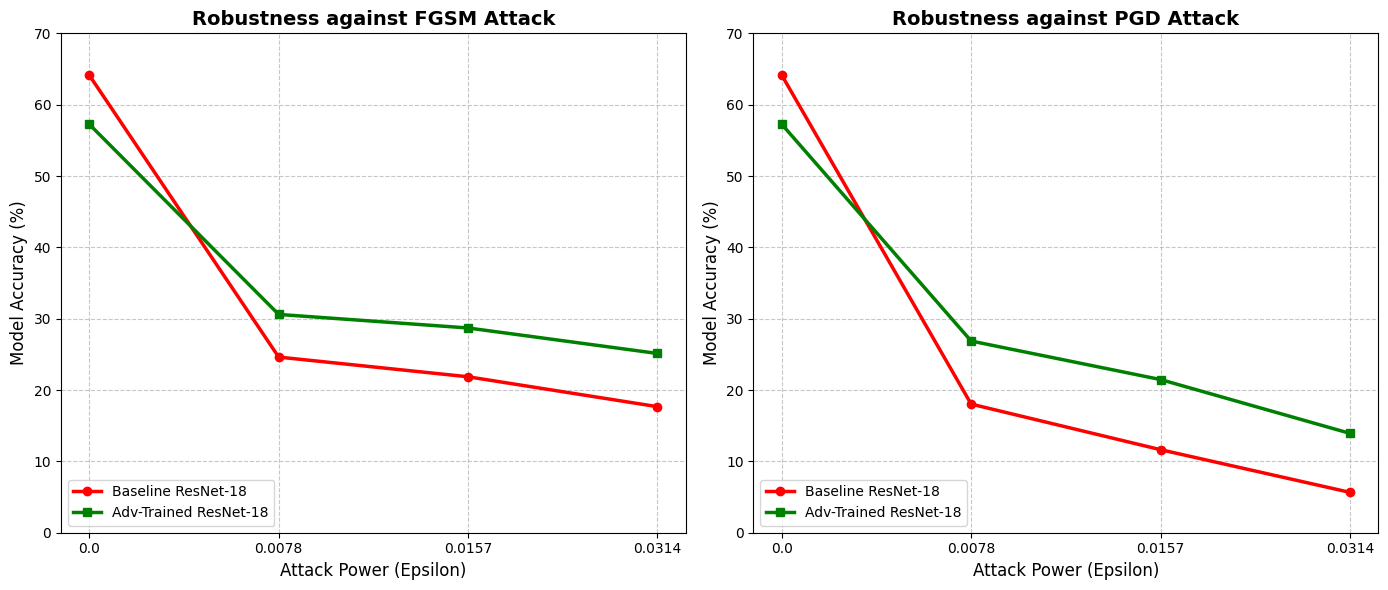


✅ Обновленные графики успешно сгенерированы и сохранены!


In [9]:
import matplotlib.pyplot as plt

eps_labels = ['0.0', '0.0078', '0.0157', '0.0314']

# Базовая модель (вчерашние данные)
base_fgsm = [64.13, 24.62, 21.86, 17.67]
base_pgd = [64.13, 18.03, 11.64, 5.66]

# НОВЫЕ ДАННЫЕ ЗАЩИЩЕННОЙ МОДЕЛИ (Смешанное обучение)
adv_fgsm_accs = [57.25, 30.60, 28.70, 25.13]
adv_pgd_accs = [57.25, 26.87, 21.47, 13.93]

plt.figure(figsize=(14, 6))

# График 1: Сравнение защиты от FGSM
plt.subplot(1, 2, 1)
plt.plot(eps_labels, base_fgsm, 'r-o', linewidth=2.5, label='Baseline ResNet-18')
plt.plot(eps_labels, adv_fgsm_accs, 'g-s', linewidth=2.5, label='Adv-Trained ResNet-18')
plt.title('Robustness against FGSM Attack', fontsize=14, fontweight='bold')
plt.xlabel('Attack Power (Epsilon)', fontsize=12)
plt.ylabel('Model Accuracy (%)', fontsize=12)
plt.ylim(0, 70)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)

# График 2: Сравнение защиты от PGD
plt.subplot(1, 2, 2)
plt.plot(eps_labels, base_pgd, 'r-o', linewidth=2.5, label='Baseline ResNet-18')
plt.plot(eps_labels, adv_pgd_accs, 'g-s', linewidth=2.5, label='Adv-Trained ResNet-18')
plt.title('Robustness against PGD Attack', fontsize=14, fontweight='bold')
plt.xlabel('Attack Power (Epsilon)', fontsize=12)
plt.ylabel('Model Accuracy (%)', fontsize=12)
plt.ylim(0, 70)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab_Data/robustness_results_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Обновленные графики успешно сгенерированы и сохранены!")

In [14]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import time

def get_vgg16_cifar(num_classes=100):
    # ФИКС: Используем vgg16_bn (с Batch Normalization), чтобы спасти градиенты
    model = models.vgg16_bn(weights=None)

    # Оставляем наш фикс размеров под CIFAR
    model.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    model.classifier = nn.Sequential(
        nn.Linear(512, 512),
        nn.BatchNorm1d(512), # Добавляем нормализацию и в классификатор
        nn.ReLU(True),
        nn.Dropout(p=0.5),
        nn.Linear(512, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(True),
        nn.Dropout(p=0.5),
        nn.Linear(512, num_classes)
    )
    return model

vgg_model = get_vgg16_cifar(num_classes=100).to(device)

# ФИКС 2: Снижаем learning rate в два раза, чтобы сеть не "перепрыгивала" решения
vgg_optimizer = optim.Adam(vgg_model.parameters(), lr=0.0005)

print(f"✅ Тяжеловес VGG-16 (с Batch Norm) успешно загружен на {device}")

✅ Тяжеловес VGG-16 (с Batch Norm) успешно загружен на cuda


In [15]:
epochs_vgg = 15
print(f"🚀 Начинаем обучение базовой модели VGG-16 ({epochs_vgg} эпох)...\n")

for epoch in range(epochs_vgg):
    start_time = time.time()
    vgg_model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        vgg_optimizer.zero_grad()
        outputs = vgg_model(inputs)

        # Используем твой старый criterion из первых ячеек
        loss = criterion(outputs, labels)
        loss.backward()
        vgg_optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # Быстрая валидация
    vgg_model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    print(f"Эпоха VGG [{epoch+1}/{epochs_vgg}] | Train Acc: {100 * correct_train / total_train:.2f}% | Test Acc: {100 * correct_test / total_test:.2f}% | Время: {time.time()-start_time:.1f} сек")

torch.save(vgg_model.state_dict(), '/content/drive/MyDrive/Colab_Data/vgg16_cifar100_base.pth')
print("\n✅ Обучение VGG-16 завершено. Веса сохранены!")

🚀 Начинаем обучение базовой модели VGG-16 (15 эпох)...

Эпоха VGG [1/15] | Train Acc: 5.95% | Test Acc: 10.33% | Время: 28.9 сек
Эпоха VGG [2/15] | Train Acc: 12.48% | Test Acc: 15.99% | Время: 28.8 сек
Эпоха VGG [3/15] | Train Acc: 17.58% | Test Acc: 22.56% | Время: 29.1 сек
Эпоха VGG [4/15] | Train Acc: 22.80% | Test Acc: 25.19% | Время: 29.7 сек
Эпоха VGG [5/15] | Train Acc: 27.28% | Test Acc: 30.68% | Время: 29.1 сек
Эпоха VGG [6/15] | Train Acc: 31.35% | Test Acc: 31.00% | Время: 28.5 сек
Эпоха VGG [7/15] | Train Acc: 34.57% | Test Acc: 37.18% | Время: 28.5 сек
Эпоха VGG [8/15] | Train Acc: 37.74% | Test Acc: 38.51% | Время: 28.5 сек
Эпоха VGG [9/15] | Train Acc: 40.39% | Test Acc: 40.58% | Время: 28.1 сек
Эпоха VGG [10/15] | Train Acc: 42.59% | Test Acc: 44.90% | Время: 28.5 сек
Эпоха VGG [11/15] | Train Acc: 44.97% | Test Acc: 42.81% | Время: 28.1 сек
Эпоха VGG [12/15] | Train Acc: 47.08% | Test Acc: 47.30% | Время: 28.3 сек
Эпоха VGG [13/15] | Train Acc: 48.92% | Test Acc: 47.1

In [17]:
import torchattacks

print("🛡️ Тестируем базовый VGG-16 под атаками...\n")
vgg_model.eval()

epsilons = [0, 2/255, 4/255, 8/255]
vgg_base_fgsm = []
vgg_base_pgd = []

for eps in epsilons:
    if eps == 0:
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = vgg_model(inputs)
                _, pred = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()
        acc = 100 * correct / total
        vgg_base_fgsm.append(acc)
        vgg_base_pgd.append(acc)
        print(f"Epsilon: 0.0000 | Точность VGG-16 (Чистые): {acc:.2f}%")
        continue

    atk_fgsm = torchattacks.FGSM(vgg_model, eps=eps)
    atk_pgd = torchattacks.PGD(vgg_model, eps=eps, alpha=eps/4, steps=7)

    correct_fgsm, correct_pgd, total = 0, 0, 0

    # FGSM
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        adv_inputs = atk_fgsm(inputs, labels)
        outputs = vgg_model(adv_inputs)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct_fgsm += (pred == labels).sum().item()

    # PGD
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        adv_inputs = atk_pgd(inputs, labels)
        outputs = vgg_model(adv_inputs)
        _, pred = torch.max(outputs, 1)
        correct_pgd += (pred == labels).sum().item()

    acc_f = 100 * correct_fgsm / total
    acc_p = 100 * correct_pgd / total
    vgg_base_fgsm.append(acc_f)
    vgg_base_pgd.append(acc_p)

    print(f"Epsilon: {eps:.4f} | FGSM Accuracy: {acc_f:.2f}% | PGD Accuracy: {acc_p:.2f}%")

🛡️ Тестируем базовый VGG-16 под атаками...

Epsilon: 0.0000 | Точность VGG-16 (Чистые): 51.42%
Epsilon: 0.0078 | FGSM Accuracy: 15.83% | PGD Accuracy: 11.91%
Epsilon: 0.0157 | FGSM Accuracy: 14.12% | PGD Accuracy: 8.26%
Epsilon: 0.0314 | FGSM Accuracy: 11.96% | PGD Accuracy: 4.31%


In [18]:
print("🛡️ ФИНАЛ: Смешанное Adversarial Training для VGG-16...\n")
adv_vgg = get_vgg16_cifar(num_classes=100).to(device)
optimizer_adv_vgg = optim.Adam(adv_vgg.parameters(), lr=0.0005)

# Быстрая атака для тренировки
atk_train_vgg = torchattacks.PGD(adv_vgg, eps=4/255, alpha=1/255, steps=3)

epochs_vgg = 15
for epoch in range(epochs_vgg):
    start_time = time.time()
    adv_vgg.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. Генерируем отравленные картинки
        adv_inputs = atk_train_vgg(inputs, labels)

        optimizer_adv_vgg.zero_grad()

        # 2. Ошибка на чистых
        outputs_clean = adv_vgg(inputs)
        loss_clean = criterion(outputs_clean, labels)

        # 3. Ошибка на атакованных
        outputs_adv = adv_vgg(adv_inputs)
        loss_adv = criterion(outputs_adv, labels)

        # 4. Смешанный опыт 50/50
        loss = 0.5 * loss_clean + 0.5 * loss_adv
        loss.backward()
        optimizer_adv_vgg.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs_clean.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = 100 * correct_train / total_train
    print(f"Эпоха защиты VGG [{epoch+1}/{epochs_vgg}] | Train Acc (Чистые): {train_acc:.2f}% | Время: {time.time()-start_time:.1f} сек")

torch.save(adv_vgg.state_dict(), '/content/drive/MyDrive/Colab_Data/vgg16_cifar100_adv_mixed.pth')
print("\n✅ Защищенный VGG-16 сохранен навсегда!")

🛡️ ФИНАЛ: Смешанное Adversarial Training для VGG-16...

Эпоха защиты VGG [1/15] | Train Acc (Чистые): 7.17% | Время: 86.4 сек
Эпоха защиты VGG [2/15] | Train Acc (Чистые): 14.52% | Время: 86.3 сек
Эпоха защиты VGG [3/15] | Train Acc (Чистые): 20.49% | Время: 86.0 сек
Эпоха защиты VGG [4/15] | Train Acc (Чистые): 25.52% | Время: 86.1 сек
Эпоха защиты VGG [5/15] | Train Acc (Чистые): 29.70% | Время: 86.0 сек
Эпоха защиты VGG [6/15] | Train Acc (Чистые): 33.72% | Время: 86.0 сек
Эпоха защиты VGG [7/15] | Train Acc (Чистые): 36.88% | Время: 86.1 сек
Эпоха защиты VGG [8/15] | Train Acc (Чистые): 39.48% | Время: 86.2 сек
Эпоха защиты VGG [9/15] | Train Acc (Чистые): 42.06% | Время: 86.2 сек
Эпоха защиты VGG [10/15] | Train Acc (Чистые): 44.28% | Время: 86.2 сек
Эпоха защиты VGG [11/15] | Train Acc (Чистые): 46.22% | Время: 86.1 сек
Эпоха защиты VGG [12/15] | Train Acc (Чистые): 48.38% | Время: 86.1 сек
Эпоха защиты VGG [13/15] | Train Acc (Чистые): 50.20% | Время: 86.1 сек
Эпоха защиты VGG [

In [19]:
print("🛡️ Тестируем защищенный VGG-16...\n")
adv_vgg.eval()

epsilons = [0, 2/255, 4/255, 8/255]
adv_vgg_fgsm_accs = []
adv_vgg_pgd_accs = []

for eps in epsilons:
    if eps == 0:
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = adv_vgg(inputs)
                _, pred = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()
        acc = 100 * correct / total
        adv_vgg_fgsm_accs.append(acc)
        adv_vgg_pgd_accs.append(acc)
        print(f"Epsilon: 0.0000 | Точность VGG-16 Adv (Чистые): {acc:.2f}%")
        continue

    atk_fgsm = torchattacks.FGSM(adv_vgg, eps=eps)
    atk_pgd = torchattacks.PGD(adv_vgg, eps=eps, alpha=eps/4, steps=7)

    correct_fgsm, correct_pgd, total = 0, 0, 0
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # FGSM
        outputs_f = adv_vgg(atk_fgsm(inputs, labels))
        _, pred_f = torch.max(outputs_f, 1)
        correct_fgsm += (pred_f == labels).sum().item()

        # PGD
        outputs_p = adv_vgg(atk_pgd(inputs, labels))
        _, pred_p = torch.max(outputs_p, 1)
        correct_pgd += (pred_p == labels).sum().item()

        total += labels.size(0)

    acc_f = 100 * correct_fgsm / total
    acc_p = 100 * correct_pgd / total
    adv_vgg_fgsm_accs.append(acc_f)
    adv_vgg_pgd_accs.append(acc_p)
    print(f"Epsilon: {eps:.4f} | Точность FGSM: {acc_f:.2f}% | Точность PGD: {acc_p:.2f}%")

print("\n🎉 КОДОВАЯ ЧАСТЬ ИССЛЕДОВАНИЯ ОФИЦИАЛЬНО ЗАВЕРШЕНА!")

🛡️ Тестируем защищенный VGG-16...

Epsilon: 0.0000 | Точность VGG-16 Adv (Чистые): 48.92%
Epsilon: 0.0078 | Точность FGSM: 24.86% | Точность PGD: 22.04%
Epsilon: 0.0157 | Точность FGSM: 23.39% | Точность PGD: 17.58%
Epsilon: 0.0314 | Точность FGSM: 20.48% | Точность PGD: 12.22%

🎉 КОДОВАЯ ЧАСТЬ ИССЛЕДОВАНИЯ ОФИЦИАЛЬНО ЗАВЕРШЕНА!


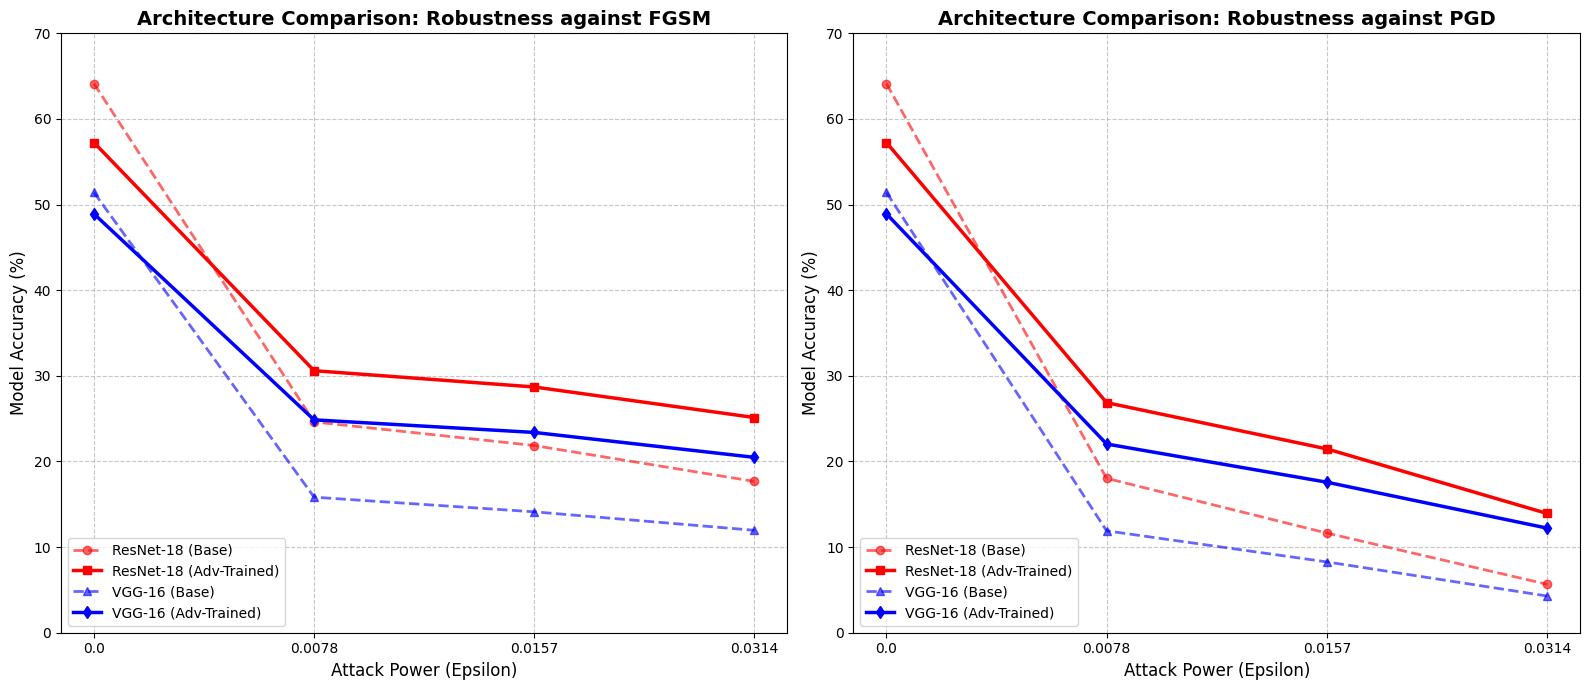


✅ Финальный сравнительный график сгенерирован и сохранен на Гугл Диск!


In [20]:
import matplotlib.pyplot as plt

eps_labels = ['0.0', '0.0078', '0.0157', '0.0314']

# --- ДАННЫЕ RESNET-18 ---
resnet_base_fgsm = [64.13, 24.62, 21.86, 17.67]
resnet_base_pgd = [64.13, 18.03, 11.64, 5.66]
resnet_adv_fgsm = [57.25, 30.60, 28.70, 25.13]
resnet_adv_pgd = [57.25, 26.87, 21.47, 13.93]

# --- ДАННЫЕ VGG-16 ---
vgg_base_fgsm = [51.42, 15.83, 14.12, 11.96]
vgg_base_pgd = [51.42, 11.90, 8.27, 4.29]
vgg_adv_fgsm = [48.92, 24.86, 23.39, 20.48]
vgg_adv_pgd = [48.92, 22.04, 17.58, 12.22]

plt.figure(figsize=(16, 7))

# График 1: Сравнение под ударом FGSM
plt.subplot(1, 2, 1)
plt.plot(eps_labels, resnet_base_fgsm, 'r--o', linewidth=2, alpha=0.6, label='ResNet-18 (Base)')
plt.plot(eps_labels, resnet_adv_fgsm, 'r-s', linewidth=2.5, label='ResNet-18 (Adv-Trained)')
plt.plot(eps_labels, vgg_base_fgsm, 'b--^', linewidth=2, alpha=0.6, label='VGG-16 (Base)')
plt.plot(eps_labels, vgg_adv_fgsm, 'b-d', linewidth=2.5, label='VGG-16 (Adv-Trained)')
plt.title('Architecture Comparison: Robustness against FGSM', fontsize=14, fontweight='bold')
plt.xlabel('Attack Power (Epsilon)', fontsize=12)
plt.ylabel('Model Accuracy (%)', fontsize=12)
plt.ylim(0, 70)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)

# График 2: Сравнение под ударом PGD
plt.subplot(1, 2, 2)
plt.plot(eps_labels, resnet_base_pgd, 'r--o', linewidth=2, alpha=0.6, label='ResNet-18 (Base)')
plt.plot(eps_labels, resnet_adv_pgd, 'r-s', linewidth=2.5, label='ResNet-18 (Adv-Trained)')
plt.plot(eps_labels, vgg_base_pgd, 'b--^', linewidth=2, alpha=0.6, label='VGG-16 (Base)')
plt.plot(eps_labels, vgg_adv_pgd, 'b-d', linewidth=2.5, label='VGG-16 (Adv-Trained)')
plt.title('Architecture Comparison: Robustness against PGD', fontsize=14, fontweight='bold')
plt.xlabel('Attack Power (Epsilon)', fontsize=12)
plt.ylabel('Model Accuracy (%)', fontsize=12)
plt.ylim(0, 70)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
# Сохраняем шедевр в максимальном качестве
plt.savefig('/content/drive/MyDrive/Colab_Data/final_architecture_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Финальный сравнительный график сгенерирован и сохранен на Гугл Диск!")